## 1. Import Libraries and Setup

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Set plotting parameters
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("🚀 All libraries imported successfully!")
print("📊 Ready to start DeepSeek Random Forest Analysis")

🚀 All libraries imported successfully!
📊 Ready to start DeepSeek Random Forest Analysis


## 2. Load and Explore Dataset

In [2]:
# Load the dataset - Update this path to match your file location
df = pd.read_csv('DeepSeek by Engineering Students_SEM & ML-Final (Responses) - Form Responses 1.csv')

# Clean column names (fix trailing spaces)
df.columns = df.columns.str.strip()

# Display basic information
print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Total Responses: {len(df)}")
print(f"📈 Total Columns: {len(df.columns)}")

# Display first few rows
print("\n📖 First 5 rows:")
df.head()

📊 Dataset Shape: (247, 30)
📋 Total Responses: 247
📈 Total Columns: 30

📖 First 5 rows:


,Timestamp,Email Address (force verified),Email Address,Gender,What is your age?,What is your current academic level?,"What is your field of engineering study? \n(Ex: Cse, Swe)",Have you used DeepSeek before?,Experience with AI tools?,1. DeepSeek helps me solve complex engineering problems more effectively. (DeepSeek আমাকে জটিল প্রকৌশল সমস্যা আরও কার্যকরভাবে সমাধান করতে সাহায্য করে),...,12. There is adequate training or documentation available for DeepSeek. (DeepSeek-এর জন্য পর্যাপ্ত প্রশিক্ষণ বা ডকুমেন্টেশন উপলব্ধ আছে),13. I believe the solutions provided by DeepSeek are reliable. (আমি বিশ্বাস করি DeepSeek দ্বারা প্রদত্ত সমাধানগুলি নির্ভরযোগ্য),14. DeepSeek produces consistent and accurate results. (DeepSeek ধারাবাহিক এবং সঠিক ফলাফল প্রদান করে),15. I trust DeepSeek to handle my academic data safely. (আমি আমার একাডেমিক ডেটা নিরাপদে পরিচালনার জন্য DeepSeek-কে বিশ্বাস করি),16. I worry DeepSeek might share my personal data without consent. (আমি চিন্তা করি DeepSeek আমার ব্যক্তিগত তথ্য অনুমতি ছাড়া শেয়ার করতে পারে),17. I am concerned that errors in DeepSeek’s solutions could negatively affect my work. (আমি উদ্বিগ্ন যে DeepSeek-এর সমাধানে ত্রুটি আমার কাজকে নেতিবাচকভাবে প্রভাবিত করতে পারে),18. I feel uncertain about the privacy of my inputs when using DeepSeek. (DeepSeek ব্যবহার করার সময় আমার ইনপুটের গোপনীয়তা নিয়ে আমি অনিশ্চিত বোধ করি),19. I intend to use DeepSeek regularly in the next semester. (আমি আগামী সেমিস্টারে নিয়মিতভাবে DeepSeek ব্যবহার করার পরিকল্পনা করছি),20. I will recommend DeepSeek to my classmates. (আমি আমার সহপাঠীদের DeepSeek ব্যবহার করার পরামর্শ দেব),21. I am willing to invest time learning more about DeepSeek features. (আমি DeepSeek-এর ফিচারগুলো সম্পর্কে আরও জানতে সময় বিনিয়োগ করতে ইচ্ছুক)
0,8/2/2025 15:38:58,islam15-5708@diu.edu.bd,NaN,Male,24 to 26,Fourth Year,CSE,Yes,High,Strongly Agree,...,Strongly Agree,Agree,Agree,Strongly Agree,Neutral,Disagree,Neutral,Agree,Agree,Disagree
1,8/2/2025 15:52:43,farhadur15-4800@diu.edu.bd,NaN,Male,24 to 26,Fourth Year,Cse,Yes,Medium,Agree,...,Neutral,Agree,Agree,Agree,Agree,Agree,Neutral,Neutral,Neutral,Neutral
2,8/2/2025 15:57:16,anikanikseo@gmail.com,NaN,Male,24 to 26,Fourth Year,CSE,Yes,Medium,Agree,...,Neutral,Agree,Agree,Neutral,Neutral,Disagree,Neutral,Agree,Agree,Agree
3,8/2/2025 16:27:07,hossain15-5963@diu.edu.bd,NaN,Male,24 to 26,Fourth Year,CSE,Yes,Medium,Agree,...,Disagree,Neutral,Neutral,Disagree,Disagree,Agree,Neutral,Disagree,Neutral,Agree
4,8/2/2025 22:57:14,khan15-5728@diu.edu.bd,NaN,Male,21 to 23,Fourth Year,Cse,Yes,High,Neutral,...,Disagree,Neutral,Neutral,Disagree,Disagree,Disagree,Neutral,Disagree,Neutral,Agree


In [3]:
# Examine column structure
print("📝 All Column Names:")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. '{col}'")

📝 All Column Names:
 1. 'Timestamp'
 2. 'Email Address (force verified)'
 3. 'Email Address'
 4. 'Gender'
 5. 'What is your age?'
 6. 'What is your current academic level?'
 7. 'What is your field of engineering study? 
(Ex: Cse, Swe)'
 8. 'Have you used DeepSeek before?'
 9. 'Experience with AI tools?'
10. '1. DeepSeek helps me solve complex engineering problems more effectively. (DeepSeek আমাকে জটিল প্রকৌশল সমস্যা আরও কার্যকরভাবে সমাধান করতে সাহায্য করে)'
11. '2. Using DeepSeek improves my academic performance (e.g. grades). (DeepSeek ব্যবহার করার ফলে আমার একাডেমিক পারফরম্যান্স (যেমন: গ্রেড) উন্নত হয়)'
12. '3. DeepSeek provides valuable insights that I couldn’t easily get otherwise. (DeepSeek আমাকে এমন মূল্যবান অন্তর্দৃষ্টি প্রদান করে, যা অন্যভাবে সহজে পাওয়া সম্ভব নয়)'
13. '4. Learning to use DeepSeek is easy for me. (DeepSeek ব্যবহার করতে শেখা আমার জন্য সহজ)'
14. '5. DeepSeek’s interface is intuitive. (DeepSeek-এর ইন্টারফেসটি সহজবোধ্য)'
15. '6. It is effortless to get DeepSeek to

## 3. Data Preprocessing and Column Mapping

In [4]:
# Find demographic columns dynamically
demographic_cols_found = []
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['gender', 'age', 'academic', 'field', 'deepseek', 'ai tools', 'experience']):
        demographic_cols_found.append(col)

print(f"🔍 Demographic columns found: {len(demographic_cols_found)}")
for col in demographic_cols_found:
    print(f"  - '{col}'")

# Find Likert scale questions (questions with numbers)
likert_questions = []
for col in df.columns:
    if any(str(i) + '.' in col for i in range(1, 22)):
        likert_questions.append(col)

print(f"\n📊 Likert Scale Questions Found: {len(likert_questions)}")
for i, col in enumerate(likert_questions[:5]):  # Show first 5
    print(f"{i+1:2d}. {col[:80]}...")

🔍 Demographic columns found: 27
  - 'Gender'
  - 'What is your age?'
  - 'What is your current academic level?'
  - 'What is your field of engineering study? 
(Ex: Cse, Swe)'
  - 'Have you used DeepSeek before?'
  - 'Experience with AI tools?'
  - '1. DeepSeek helps me solve complex engineering problems more effectively. (DeepSeek আমাকে জটিল প্রকৌশল সমস্যা আরও কার্যকরভাবে সমাধান করতে সাহায্য করে)'
  - '2. Using DeepSeek improves my academic performance (e.g. grades). (DeepSeek ব্যবহার করার ফলে আমার একাডেমিক পারফরম্যান্স (যেমন: গ্রেড) উন্নত হয়)'
  - '3. DeepSeek provides valuable insights that I couldn’t easily get otherwise. (DeepSeek আমাকে এমন মূল্যবান অন্তর্দৃষ্টি প্রদান করে, যা অন্যভাবে সহজে পাওয়া সম্ভব নয়)'
  - '4. Learning to use DeepSeek is easy for me. (DeepSeek ব্যবহার করতে শেখা আমার জন্য সহজ)'
  - '5. DeepSeek’s interface is intuitive. (DeepSeek-এর ইন্টারফেসটি সহজবোধ্য)'
  - '6. It is effortless to get DeepSeek to perform the tasks I need. (আমার প্রয়োজনীয় কাজগুলো করাতে De

In [5]:
# Create demographic column mappings
actual_demographic_mapping = {}

for col in df.columns:
    if col == 'Gender':
        actual_demographic_mapping['Gender'] = 'Gender'
    elif 'age' in col.lower():
        actual_demographic_mapping[col] = 'Age'
    elif 'academic level' in col.lower():
        actual_demographic_mapping[col] = 'Academic_Level'
    elif 'field of engineering study' in col.lower():
        actual_demographic_mapping[col] = 'Field_Study'
    elif 'deepseek before' in col.lower():
        actual_demographic_mapping[col] = 'Used_DeepSeek_Before'
    elif 'ai tools' in col.lower():
        actual_demographic_mapping[col] = 'AI_Experience'

print("🔄 Demographic column mappings:")
for original, new in actual_demographic_mapping.items():
    print(f"  '{original}' → '{new}'")

print(f"\n✅ Found {len(actual_demographic_mapping)} demographic mappings")

🔄 Demographic column mappings:
  'Gender' → 'Gender'
  'What is your age?' → 'Age'
  'What is your current academic level?' → 'Academic_Level'
  'What is your field of engineering study? 
(Ex: Cse, Swe)' → 'Field_Study'
  'Have you used DeepSeek before?' → 'Used_DeepSeek_Before'
  'Experience with AI tools?' → 'AI_Experience'
  '7.  My classmates encourage me to use DeepSeek.(আমার সহপাঠীরা আমাকে DeepSeek ব্যবহার করতে উৎসাহিত করে)' → 'Age'

✅ Found 7 demographic mappings


In [6]:
# Create UTAUT construct mappings
construct_mapping = {}

if len(likert_questions) >= 21:
    construct_mapping = {
        # Performance Expectancy (PE) - Items 1, 2, 3
        likert_questions[0]: 'PE1',  # DeepSeek helps solve problems
        likert_questions[1]: 'PE2',  # Improves academic performance
        likert_questions[2]: 'PE3',  # Provides valuable insights

        # Effort Expectancy (EE) - Items 4, 5, 6
        likert_questions[3]: 'EE1',  # Easy to learn
        likert_questions[4]: 'EE2',  # Intuitive interface
        likert_questions[5]: 'EE3',  # Effortless to use

        # Social Influence (SI) - Items 7, 8, 9
        likert_questions[6]: 'SI1',  # Classmates encourage
        likert_questions[7]: 'SI2',  # Instructors recommend
        likert_questions[8]: 'SI3',  # Influential people think should adopt

        # Facilitating Conditions (FC) - Items 10, 11, 12
        likert_questions[9]: 'FC1',   # Necessary resources
        likert_questions[10]: 'FC2',  # IT support available
        likert_questions[11]: 'FC3',  # Training/documentation available

        # Trust (TR) - Items 13, 14, 15
        likert_questions[12]: 'TR1',  # Solutions are reliable
        likert_questions[13]: 'TR2',  # Consistent and accurate
        likert_questions[14]: 'TR3',  # Trust with academic data

        # Perceived Risk (PR) - Items 16, 17, 18
        likert_questions[15]: 'PR1',  # Worry about data sharing
        likert_questions[16]: 'PR2',  # Concerned about errors
        likert_questions[17]: 'PR3',  # Uncertain about privacy

        # Behavioral Intention (BI) - Items 19, 20, 21
        likert_questions[18]: 'BI1',  # Intend to use regularly
        likert_questions[19]: 'BI2',  # Will recommend
        likert_questions[20]: 'BI3',  # Willing to invest time learning
    }

    print(f"✅ UTAUT construct mappings created: {len(construct_mapping)}")
    print("📋 Construct breakdown:")
    print("  - Performance Expectancy (PE): 3 items")
    print("  - Effort Expectancy (EE): 3 items")
    print("  - Social Influence (SI): 3 items")
    print("  - Facilitating Conditions (FC): 3 items")
    print("  - Trust (TR): 3 items")
    print("  - Perceived Risk (PR): 3 items")
    print("  - Behavioral Intention (BI): 3 items")
else:
    print(f"⚠️ WARNING: Expected 21 Likert questions, found {len(likert_questions)}")
    print("Some constructs may be incomplete.")

print(f"\n📊 Construct mapping summary: {len(construct_mapping)} items mapped")

✅ UTAUT construct mappings created: 21
📋 Construct breakdown:
  - Performance Expectancy (PE): 3 items
  - Effort Expectancy (EE): 3 items
  - Social Influence (SI): 3 items
  - Facilitating Conditions (FC): 3 items
  - Trust (TR): 3 items
  - Perceived Risk (PR): 3 items
  - Behavioral Intention (BI): 3 items

📊 Construct mapping summary: 21 items mapped


In [7]:
# Apply all mappings to create clean dataset
all_mappings = {**actual_demographic_mapping, **construct_mapping}
df_clean = df.rename(columns=all_mappings)

print(f"🔄 Applied {len(all_mappings)} column mappings successfully!")
print(f"📊 Cleaned dataset shape: {df_clean.shape}")

# Show sample of cleaned column names
print(f"\n📋 Sample of cleaned column names:")
sample_cols = [col for col in df_clean.columns if col in ['Gender', 'Age', 'PE1', 'PE2', 'SI1', 'TR1', 'BI1']]
for col in sample_cols:
    print(f"  ✅ {col}")

print(f"\n🎯 Ready for data analysis!")

🔄 Applied 27 column mappings successfully!
📊 Cleaned dataset shape: (247, 30)

📋 Sample of cleaned column names:
  ✅ Gender
  ✅ Age
  ✅ PE1
  ✅ PE2
  ✅ SI1
  ✅ TR1
  ✅ BI1

🎯 Ready for data analysis!


## 4. Analyze Demographic Data

In [8]:
# Analyze demographic distributions
demographic_cols = ['Gender', 'Age', 'Academic_Level', 'Field_Study', 'AI_Experience', 'Used_DeepSeek_Before']

print("👥 DEMOGRAPHIC DATA ANALYSIS")
print("="*50)

for col in demographic_cols:
    if col in df_clean.columns:
        print(f"\n📊 {col}:")
        value_counts = df_clean[col].value_counts()
        for value, count in value_counts.items():
            percentage = (count / len(df_clean)) * 100
            print(f"  {value}: {count} ({percentage:.1f}%)")
    else:
        print(f"\n❌ {col}: Column not found")

👥 DEMOGRAPHIC DATA ANALYSIS

📊 Gender:
  Male: 218 (88.3%)
  Female: 29 (11.7%)

📊 Age:
  21 to 23: 128 (51.8%)
  24 to 26: 100 (40.5%)
  18 to 20: 16 (6.5%)
  27 to 29: 3 (1.2%)

📊 Academic_Level:
  Fourth Year: 153 (61.9%)
  First Year: 36 (14.6%)
  Third Year: 28 (11.3%)
  Second Year: 27 (10.9%)
  Postgraduate (Master's/PhD): 3 (1.2%)

📊 Field_Study:
  Cse: 76 (30.8%)
  CSE: 74 (30.0%)
  SWE: 14 (5.7%)
  EEE: 12 (4.9%)
  Swe: 12 (4.9%)
  cse: 9 (3.6%)
  CSE : 7 (2.8%)
  CE: 5 (2.0%)
  Pharmacy : 4 (1.6%)
  NFE: 3 (1.2%)
  BBA: 3 (1.2%)
  CIS: 2 (0.8%)
  TE: 2 (0.8%)
  Cse : 2 (0.8%)
  Eee: 2 (0.8%)
  swe: 2 (0.8%)
  Caey: 1 (0.4%)
  pharmacy : 1 (0.4%)
  Bba: 1 (0.4%)
  Te: 1 (0.4%)
  Civil: 1 (0.4%)
  Computer: 1 (0.4%)
  Mct: 1 (0.4%)
  yes: 1 (0.4%)
  ESDM: 1 (0.4%)
  Swe : 1 (0.4%)
  Cis: 1 (0.4%)
  ICE: 1 (0.4%)
  No: 1 (0.4%)
  GEB: 1 (0.4%)
  Non: 1 (0.4%)
  English : 1 (0.4%)
  Ce: 1 (0.4%)
  CIS : 1 (0.4%)

📊 AI_Experience:
  Medium: 148 (59.9%)
  High: 85 (34.4%)
  Low: 1

In [9]:
# Check for missing values
print("🔍 MISSING VALUES ANALYSIS")
print("="*30)

missing_counts = df_clean.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]

if len(missing_cols) > 0:
    print("⚠️ Columns with missing values:")
    for col, count in missing_cols.items():
        print(f"  {col}: {count} missing values ({count/len(df_clean)*100:.1f}%)")
else:
    print("✅ No missing values found in survey data!")

print(f"\n📊 Dataset completeness: {((len(df_clean.columns) * len(df_clean)) - missing_counts.sum()) / (len(df_clean.columns) * len(df_clean)) * 100:.1f}%")

🔍 MISSING VALUES ANALYSIS
⚠️ Columns with missing values:
  Email Address (force verified): 8 missing values (3.2%)
  Email Address: 239 missing values (96.8%)

📊 Dataset completeness: 96.7%


## 5. Convert Likert Scale to Numeric Values

In [10]:
# Define Likert scale mapping
likert_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5
}

# Identify existing Likert columns
likert_cols = ['PE1', 'PE2', 'PE3', 'EE1', 'EE2', 'EE3', 'SI1', 'SI2', 'SI3',
               'FC1', 'FC2', 'FC3', 'TR1', 'TR2', 'TR3', 'PR1', 'PR2', 'PR3',
               'BI1', 'BI2', 'BI3']

existing_likert_cols = [col for col in likert_cols if col in df_clean.columns]

print(f"🔢 LIKERT SCALE CONVERSION")
print(f"📊 Found {len(existing_likert_cols)} Likert columns")
print(f"📋 Columns: {existing_likert_cols}")
print(f"🔄 Mapping: {likert_mapping}")

🔢 LIKERT SCALE CONVERSION
📊 Found 21 Likert columns
📋 Columns: ['PE1', 'PE2', 'PE3', 'EE1', 'EE2', 'EE3', 'SI1', 'SI2', 'SI3', 'FC1', 'FC2', 'FC3', 'TR1', 'TR2', 'TR3', 'PR1', 'PR2', 'PR3', 'BI1', 'BI2', 'BI3']
🔄 Mapping: {'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5}


In [11]:
# Convert Likert responses to numeric
conversion_successful = 0
conversion_failed = 0

print(f"\n🔄 Converting Likert scale responses...")

for col in existing_likert_cols:
    # Check unique values before conversion
    unique_before = df_clean[col].unique()
    print(f"\n🔄 Converting {col}...")
    print(f"  Original values: {len(unique_before)} unique values")

    # Apply mapping
    df_clean[col] = df_clean[col].map(likert_mapping)

    # Check conversion success
    null_count = df_clean[col].isnull().sum()
    if null_count > 0:
        print(f"  ⚠️ {null_count} unmapped values")
        conversion_failed += 1
    else:
        print(f"  ✅ Success - Range: {df_clean[col].min():.0f} to {df_clean[col].max():.0f}")
        conversion_successful += 1

print(f"\n📈 Conversion Summary: {conversion_successful} successful, {conversion_failed} failed")
print(f"✅ Likert scale conversion completed!")


🔄 Converting Likert scale responses...

🔄 Converting PE1...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting PE2...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting PE3...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting EE1...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting EE2...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting EE3...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting SI1...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting SI2...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting SI3...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting FC1...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting FC2...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting FC3...
  Original valu

## 6. Create Target Variable (High_BI)

In [12]:
# Check availability of BI columns
bi_cols = ['BI1', 'BI2', 'BI3']
available_bi_cols = [col for col in bi_cols if col in df_clean.columns]

print(f"🎯 TARGET VARIABLE CREATION")
print(f"📊 Available BI columns: {available_bi_cols}")

if len(available_bi_cols) == 3:
    print("\n📊 Behavioral Intention Statistics:")

    # Show statistics for each BI item
    bi_descriptions = ['Intend to use regularly', 'Will recommend', 'Willing to invest time']

    for i, col in enumerate(available_bi_cols):
        print(f"\n{col} - {bi_descriptions[i]}:")
        stats = df_clean[col].describe()
        print(f"  Mean: {stats['mean']:.2f}, Std: {stats['std']:.2f}")
        print(f"  Range: {stats['min']:.0f} - {stats['max']:.0f}")
        value_dist = df_clean[col].value_counts().sort_index()
        print(f"  Distribution: {dict(value_dist)}")

    print(f"\n✅ All BI columns available for target creation")
else:
    print(f"❌ ERROR: Need all 3 BI columns, only found {len(available_bi_cols)}: {available_bi_cols}")
    print("Cannot proceed without complete Behavioral Intention data.")

🎯 TARGET VARIABLE CREATION
📊 Available BI columns: ['BI1', 'BI2', 'BI3']

📊 Behavioral Intention Statistics:

BI1 - Intend to use regularly:
  Mean: 3.19, Std: 1.00
  Range: 1 - 5
  Distribution: {1: np.int64(18), 2: np.int64(35), 3: np.int64(92), 4: np.int64(86), 5: np.int64(16)}

BI2 - Will recommend:
  Mean: 3.33, Std: 1.00
  Range: 1 - 5
  Distribution: {1: np.int64(13), 2: np.int64(31), 3: np.int64(89), 4: np.int64(89), 5: np.int64(25)}

BI3 - Willing to invest time:
  Mean: 3.40, Std: 0.97
  Range: 1 - 5
  Distribution: {1: np.int64(13), 2: np.int64(25), 3: np.int64(82), 4: np.int64(105), 5: np.int64(22)}

✅ All BI columns available for target creation


In [13]:
# Create target variable High_BI
if len(available_bi_cols) == 3:
    # Calculate average BI score
    df_clean['BI_avg'] = (df_clean['BI1'] + df_clean['BI2'] + df_clean['BI3']) / 3

    # Create High_BI target variable (High_BI = 1 if BI_avg >= 4, else 0)
    df_clean['High_BI'] = (df_clean['BI_avg'] >= 4).astype(int)

    print(f"🎯 Target Variable Results:")
    print(f"📊 BI Average Range: {df_clean['BI_avg'].min():.2f} - {df_clean['BI_avg'].max():.2f}")
    print(f"📊 BI Average Mean: {df_clean['BI_avg'].mean():.2f} ± {df_clean['BI_avg'].std():.2f}")

    high_bi_count = (df_clean['BI_avg'] >= 4).sum()
    low_bi_count = (df_clean['BI_avg'] < 4).sum()

    print(f"\n🎯 High_BI Distribution:")
    print(f"  High Intention (BI ≥ 4): {high_bi_count} students ({high_bi_count/len(df_clean)*100:.1f}%)")
    print(f"  Low Intention (BI < 4): {low_bi_count} students ({low_bi_count/len(df_clean)*100:.1f}%)")

    # Show sample calculations
    print("\n📋 Sample BI Calculations:")
    sample_df = df_clean[['BI1', 'BI2', 'BI3', 'BI_avg', 'High_BI']].head(10)
    display(sample_df)

    print(f"\n✅ Target variable 'High_BI' created successfully!")
else:
    print("❌ Cannot create target variable without complete BI data")

🎯 Target Variable Results:
📊 BI Average Range: 1.00 - 5.00
📊 BI Average Mean: 3.31 ± 0.81

🎯 High_BI Distribution:
  High Intention (BI ≥ 4): 76 students (30.8%)
  Low Intention (BI < 4): 171 students (69.2%)

📋 Sample BI Calculations:


,BI1,BI2,BI3,BI_avg,High_BI
0,4,4,2,3.333333,0
1,3,3,3,3.000000,0
2,4,4,4,4.000000,1
3,2,3,4,3.000000,0
4,2,3,4,3.000000,0
5,3,3,4,3.333333,0
6,3,4,4,3.666667,0
7,2,3,4,3.000000,0
8,3,3,3,3.000000,0
9,5,3,2,3.333333,0



✅ Target variable 'High_BI' created successfully!


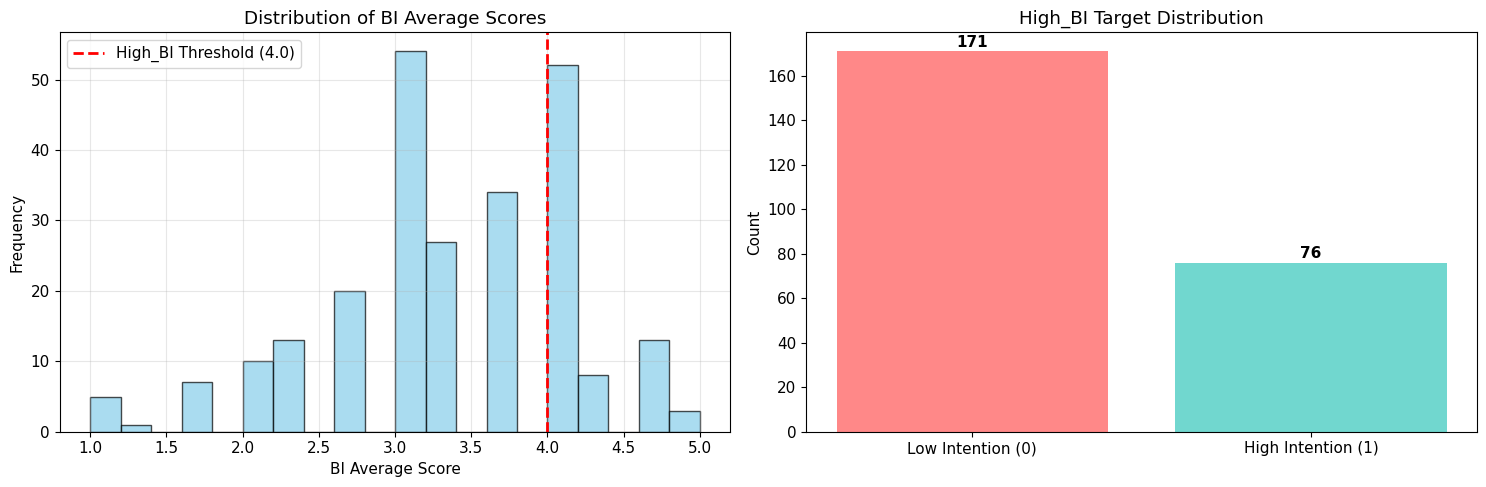

In [14]:
# Visualize target variable distribution
if 'High_BI' in df_clean.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # BI Average distribution
    ax1.hist(df_clean['BI_avg'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(x=4, color='red', linestyle='--', linewidth=2, label='High_BI Threshold (4.0)')
    ax1.set_xlabel('BI Average Score')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of BI Average Scores')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # High_BI distribution
    high_bi_counts = df_clean['High_BI'].value_counts()
    ax2.bar(['Low Intention (0)', 'High Intention (1)'], high_bi_counts.values,
            color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax2.set_ylabel('Count')
    ax2.set_title('High_BI Target Distribution')
    for i, v in enumerate(high_bi_counts.values):
        ax2.text(i, v + 2, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("❌ Cannot visualize target variable - not created")

## 7. Prepare Features for Machine Learning

In [15]:
# Select features (exclude BI items from predictors since they're used for target)
available_likert_features = [col for col in existing_likert_cols if col not in ['BI1', 'BI2', 'BI3']]

# Select demographic features that exist
potential_demographic_features = ['Gender', 'Age', 'Academic_Level', 'Field_Study', 'AI_Experience', 'Used_DeepSeek_Before']
demographic_features = [col for col in potential_demographic_features if col in df_clean.columns]

print(f"🔧 FEATURE PREPARATION")
print(f"📊 Available Likert features ({len(available_likert_features)}):")
for i, feature in enumerate(available_likert_features):
    print(f"  {i+1:2d}. {feature}")

print(f"\n👥 Available demographic features ({len(demographic_features)}):")
for i, feature in enumerate(demographic_features):
    print(f"  {i+1}. {feature}")

🔧 FEATURE PREPARATION
📊 Available Likert features (18):
   1. PE1
   2. PE2
   3. PE3
   4. EE1
   5. EE2
   6. EE3
   7. SI1
   8. SI2
   9. SI3
  10. FC1
  11. FC2
  12. FC3
  13. TR1
  14. TR2
  15. TR3
  16. PR1
  17. PR2
  18. PR3

👥 Available demographic features (6):
  1. Gender
  2. Age
  3. Academic_Level
  4. Field_Study
  5. AI_Experience
  6. Used_DeepSeek_Before


In [16]:
# Clean Field_Study if it exists
if 'Field_Study' in df_clean.columns:
    print(f"🧹 Cleaning Field_Study column...")

    # Standardize case
    df_clean['Field_Study'] = df_clean['Field_Study'].str.upper().str.strip()

    print(f"\n📊 Original Field_Study distribution:")
    original_dist = df_clean['Field_Study'].value_counts()
    for value, count in original_dist.head(10).items():  # Show top 10
        print(f"  {value}: {count}")
    if len(original_dist) > 10:
        print(f"  ... and {len(original_dist)-10} more values")

    # Group similar fields
    field_mapping = {
        'CSE': 'CSE', 'CSE ': 'CSE',
        'SWE': 'SWE', 'SWE ': 'SWE',
        'EEE': 'EEE',
        'CE': 'CE', 'CIVIL': 'CE',
        'CIS': 'CIS',
        'TE': 'TE',
        'ICE': 'ICE',
        'NFE': 'NFE',
        'PHARMACY': 'PHARMACY',
        'BBA': 'BBA',
        'COMPUTER': 'CSE',
        'MCT': 'CSE',
        'CAEY': 'OTHER',
        'YES': 'OTHER',
        'NO': 'OTHER',
        'GEB': 'OTHER',
        'NON': 'OTHER',
        'ENGLISH': 'OTHER',
        'ESDM': 'OTHER'
    }

    df_clean['Field_Study_Clean'] = df_clean['Field_Study'].map(field_mapping).fillna('OTHER')

    print(f"\n🔄 Cleaned Field_Study distribution:")
    cleaned_dist = df_clean['Field_Study_Clean'].value_counts()
    for value, count in cleaned_dist.items():
        print(f"  {value}: {count} ({count/len(df_clean)*100:.1f}%)")

    # Update demographic features list
    if 'Field_Study' in demographic_features:
        demographic_features.remove('Field_Study')
        demographic_features.append('Field_Study_Clean')

    print(f"✅ Field_Study cleaned and mapped")
else:
    print(f"ℹ️ Field_Study column not found - skipping cleaning")

print(f"\n✅ Final demographic features: {demographic_features}")

🧹 Cleaning Field_Study column...

📊 Original Field_Study distribution:
  CSE: 168
  SWE: 29
  EEE: 14
  CE: 6
  PHARMACY: 5
  CIS: 4
  BBA: 4
  NFE: 3
  TE: 3
  CIVIL: 1
  ... and 10 more values

🔄 Cleaned Field_Study distribution:
  CSE: 170 (68.8%)
  SWE: 29 (11.7%)
  EEE: 14 (5.7%)
  OTHER: 7 (2.8%)
  CE: 7 (2.8%)
  PHARMACY: 5 (2.0%)
  CIS: 4 (1.6%)
  BBA: 4 (1.6%)
  NFE: 3 (1.2%)
  TE: 3 (1.2%)
  ICE: 1 (0.4%)
✅ Field_Study cleaned and mapped

✅ Final demographic features: ['Gender', 'Age', 'Academic_Level', 'AI_Experience', 'Used_DeepSeek_Before', 'Field_Study_Clean']


## 8. Encode Categorical Variables

In [17]:
# Create copy for ML processing
df_ml = df_clean.copy()

# Label encode categorical variables
label_encoders = {}

print(f"🔢 CATEGORICAL VARIABLE ENCODING")
print(f"="*40)

for col in demographic_features:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[col + '_encoded'] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le

        print(f"\n🔄 {col} encoding:")
        encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
        for original, encoded in list(encoding_map.items())[:5]:  # Show first 5
            print(f"  '{original}' → {encoded}")
        if len(encoding_map) > 5:
            print(f"  ... and {len(encoding_map)-5} more values")
        print(f"  ✅ {len(encoding_map)} categories encoded")

🔢 CATEGORICAL VARIABLE ENCODING

🔄 Gender encoding:
  'Female' → 0
  'Male' → 1
  ✅ 2 categories encoded

🔄 Age encoding:
  '18 to 20' → 0
  '21 to 23' → 1
  '24 to 26' → 2
  '27 to 29' → 3
  ✅ 4 categories encoded

🔄 Academic_Level encoding:
  'First Year' → 0
  'Fourth Year' → 1
  'Postgraduate (Master's/PhD)' → 2
  'Second Year' → 3
  'Third Year' → 4
  ✅ 5 categories encoded

🔄 AI_Experience encoding:
  'High' → 0
  'Low' → 1
  'Medium' → 2
  ✅ 3 categories encoded

🔄 Used_DeepSeek_Before encoding:
  'No' → 0
  'Yes' → 1
  ✅ 2 categories encoded

🔄 Field_Study_Clean encoding:
  'BBA' → 0
  'CE' → 1
  'CIS' → 2
  'CSE' → 3
  'EEE' → 4
  ... and 6 more values
  ✅ 11 categories encoded


In [18]:
# Create feature matrix and target vector
X_features = available_likert_features + [col + '_encoded' for col in demographic_features]
X = df_ml[X_features].copy()
y = df_ml['High_BI'].copy()

print(f"📊 FEATURE MATRIX SUMMARY")
print(f"="*30)
print(f"📈 Total features: {len(X_features)}")
print(f"📊 Likert features: {len(available_likert_features)}")
print(f"👥 Demographic features: {len(demographic_features)}")

print(f"\n📋 All feature names:")
for i, feature in enumerate(X_features):
    print(f"  {i+1:2d}. {feature}")

print(f"\n🎯 Target variable distribution:")
target_dist = y.value_counts()
for value, count in target_dist.items():
    print(f"  {value}: {count} ({count/len(y)*100:.1f}%)")

print(f"\n📏 Data shapes:")
print(f"  Feature matrix (X): {X.shape}")
print(f"  Target vector (y): {y.shape}")
print(f"  Positive class ratio: {y.mean():.3f}")

# Check for missing values
missing_features = X.isnull().sum()
if missing_features.sum() > 0:
    print(f"\n⚠️ Missing values in features:")
    for feature, count in missing_features[missing_features > 0].items():
        print(f"  {feature}: {count} missing")
else:
    print(f"\n✅ No missing values in feature matrix")

📊 FEATURE MATRIX SUMMARY
📈 Total features: 24
📊 Likert features: 18
👥 Demographic features: 6

📋 All feature names:
   1. PE1
   2. PE2
   3. PE3
   4. EE1
   5. EE2
   6. EE3
   7. SI1
   8. SI2
   9. SI3
  10. FC1
  11. FC2
  12. FC3
  13. TR1
  14. TR2
  15. TR3
  16. PR1
  17. PR2
  18. PR3
  19. Gender_encoded
  20. Age_encoded
  21. Academic_Level_encoded
  22. AI_Experience_encoded
  23. Used_DeepSeek_Before_encoded
  24. Field_Study_Clean_encoded

🎯 Target variable distribution:
  0: 171 (69.2%)
  1: 76 (30.8%)

📏 Data shapes:
  Feature matrix (X): (247, 24)
  Target vector (y): (247,)
  Positive class ratio: 0.308

✅ No missing values in feature matrix


## 9. Split Data and Train Random Forest Model

In [19]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class distribution
)

print(f"🔀 DATA SPLITTING")
print(f"="*20)
print(f"📊 Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"📊 Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()

print(f"\n🎯 Training set High_BI distribution:")
for value, count in train_dist.items():
    print(f"  {value}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\n🎯 Test set High_BI distribution:")
for value, count in test_dist.items():
    print(f"  {value}: {count} ({count/len(y_test)*100:.1f}%)")

print(f"\n✅ Data split maintains class distribution")

🔀 DATA SPLITTING
📊 Training set: 197 samples (80%)
📊 Test set: 50 samples (20%)

🎯 Training set High_BI distribution:
  0: 136 (69.0%)
  1: 61 (31.0%)

🎯 Test set High_BI distribution:
  0: 35 (70.0%)
  1: 15 (30.0%)

✅ Data split maintains class distribution


In [20]:
# Initialize and train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=10,           # Maximum depth to prevent overfitting
    min_samples_split=5,    # Minimum samples required to split
    min_samples_leaf=2,     # Minimum samples in leaf node
    max_features='sqrt',    # Number of features for best split
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

print(f"🤖 RANDOM FOREST MODEL CONFIGURATION")
print(f"="*40)
print(f"🌳 n_estimators: {rf_model.n_estimators}")
print(f"📏 max_depth: {rf_model.max_depth}")
print(f"📊 min_samples_split: {rf_model.min_samples_split}")
print(f"🍃 min_samples_leaf: {rf_model.min_samples_leaf}")
print(f"🎯 max_features: {rf_model.max_features}")
print(f"⚖️ class_weight: {rf_model.class_weight}")

# Train the model
print(f"\n🚀 Training Random Forest model...")
rf_model.fit(X_train, y_train)
print(f"✅ Model training completed!")

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"\n📊 PREDICTION SUMMARY")
print(f"🎯 Predicted High_BI=1: {sum(y_pred)} out of {len(y_pred)} test samples")
print(f"🎯 Actual High_BI=1: {sum(y_test)} out of {len(y_test)} test samples")
print(f"📈 Prediction probability range: {y_pred_proba.min():.3f} - {y_pred_proba.max():.3f}")
print(f"📈 Mean prediction probability: {y_pred_proba.mean():.3f}")

🤖 RANDOM FOREST MODEL CONFIGURATION
🌳 n_estimators: 100
📏 max_depth: 10
📊 min_samples_split: 5
🍃 min_samples_leaf: 2
🎯 max_features: sqrt
⚖️ class_weight: balanced

🚀 Training Random Forest model...
✅ Model training completed!

📊 PREDICTION SUMMARY
🎯 Predicted High_BI=1: 15 out of 50 test samples
🎯 Actual High_BI=1: 15 out of 50 test samples
📈 Prediction probability range: 0.008 - 0.960
📈 Mean prediction probability: 0.399


## 10. Model Evaluation

In [21]:
# Calculate basic metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"📊 MODEL PERFORMANCE ON TEST SET")
print(f"="*35)
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"📈 ROC AUC Score: {roc_auc:.4f}")

# Detailed classification report
print(f"\n📋 DETAILED CLASSIFICATION REPORT")
print(f"="*35)
class_report = classification_report(y_test, y_pred, target_names=['Low Intention (0)', 'High Intention (1)'])
print(class_report)

# Confusion matrix analysis
print(f"🔢 CONFUSION MATRIX ANALYSIS")
print(f"="*30)
print(f"Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Matrix Breakdown:")
print(f"  True Negatives (TN): {tn} - Correctly predicted Low Intention")
print(f"  False Positives (FP): {fp} - Incorrectly predicted High Intention")
print(f"  False Negatives (FN): {fn} - Incorrectly predicted Low Intention")
print(f"  True Positives (TP): {tp} - Correctly predicted High Intention")

📊 MODEL PERFORMANCE ON TEST SET
🎯 Accuracy: 0.7600 (76.0%)
📈 ROC AUC Score: 0.7829

📋 DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

 Low Intention (0)       0.83      0.83      0.83        35
High Intention (1)       0.60      0.60      0.60        15

          accuracy                           0.76        50
         macro avg       0.71      0.71      0.71        50
      weighted avg       0.76      0.76      0.76        50

🔢 CONFUSION MATRIX ANALYSIS
Confusion Matrix:
[[29  6]
 [ 6  9]]

📊 Matrix Breakdown:
  True Negatives (TN): 29 - Correctly predicted Low Intention
  False Positives (FP): 6 - Incorrectly predicted High Intention
  False Negatives (FN): 6 - Incorrectly predicted Low Intention
  True Positives (TP): 9 - Correctly predicted High Intention


In [22]:
# Calculate additional metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"📈 ADDITIONAL PERFORMANCE METRICS")
print(f"="*35)
print(f"🎯 Precision (High Intention): {precision:.4f} ({precision*100:.1f}%)")
print(f"🔍 Recall/Sensitivity: {recall:.4f} ({recall*100:.1f}%)")
print(f"🛡️ Specificity: {specificity:.4f} ({specificity*100:.1f}%)")
print(f"⚖️ F1-Score: {f1_score:.4f}")

# Performance interpretation
print(f"\n📝 INTERPRETATION:")
print(f"  • Accuracy: {accuracy*100:.1f}% of predictions are correct")
print(f"  • Precision: {precision*100:.1f}% of predicted high-intention students actually have high intention")
print(f"  • Recall: {recall*100:.1f}% of actual high-intention students are correctly identified")
print(f"  • Specificity: {specificity*100:.1f}% of actual low-intention students are correctly identified")

📈 ADDITIONAL PERFORMANCE METRICS
🎯 Precision (High Intention): 0.6000 (60.0%)
🔍 Recall/Sensitivity: 0.6000 (60.0%)
🛡️ Specificity: 0.8286 (82.9%)
⚖️ F1-Score: 0.6000

📝 INTERPRETATION:
  • Accuracy: 76.0% of predictions are correct
  • Precision: 60.0% of predicted high-intention students actually have high intention
  • Recall: 60.0% of actual high-intention students are correctly identified
  • Specificity: 82.9% of actual low-intention students are correctly identified


In [23]:
# Cross-validation evaluation
print(f"🔄 CROSS-VALIDATION EVALUATION")
print(f"="*35)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
cv_roc_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')

print(f"📊 5-Fold Cross-Validation Results:")
print(f"  Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  ROC AUC: {cv_roc_scores.mean():.4f} ± {cv_roc_scores.std():.4f}")

print(f"\n📈 Individual CV Fold Results:")
for i, (acc, auc) in enumerate(zip(cv_scores, cv_roc_scores)):
    print(f"  Fold {i+1}: Accuracy={acc:.3f}, ROC AUC={auc:.3f}")

# Model stability assessment
cv_stability = cv_scores.std() / cv_scores.mean()
if cv_stability < 0.05:
    stability_status = "🟢 Very Stable"
elif cv_stability < 0.10:
    stability_status = "🟡 Stable"
elif cv_stability < 0.15:
    stability_status = "🟠 Moderately Stable"
else:
    stability_status = "🔴 Unstable"

print(f"\n🎯 Model Stability Assessment: {stability_status}")
print(f"   Coefficient of Variation: {cv_stability:.3f}")

🔄 CROSS-VALIDATION EVALUATION
📊 5-Fold Cross-Validation Results:
  Accuracy: 0.7814 ± 0.0583
  ROC AUC: 0.8374 ± 0.0400

📈 Individual CV Fold Results:
  Fold 1: Accuracy=0.850, ROC AUC=0.848
  Fold 2: Accuracy=0.775, ROC AUC=0.860
  Fold 3: Accuracy=0.718, ROC AUC=0.778
  Fold 4: Accuracy=0.846, ROC AUC=0.892
  Fold 5: Accuracy=0.718, ROC AUC=0.809

🎯 Model Stability Assessment: 🟡 Stable
   Coefficient of Variation: 0.075


## 11. Feature Importance Analysis

In [24]:
# Get feature importances
feature_importance = rf_model.feature_importances_
feature_names_list = X.columns.tolist()

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names_list,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(f"🏆 FEATURE IMPORTANCE ANALYSIS")
print(f"="*35)
print(f"\n📊 Top 15 Most Important Features:")
for i, (idx, row) in enumerate(importance_df.head(15).iterrows()):
    print(f"  {i+1:2d}. {row['Feature']:25s}: {row['Importance']:.4f} ({row['Importance']*100:.1f}%)")

# Identify feature types
likert_importance = importance_df[importance_df['Feature'].isin(available_likert_features)]
demographic_importance = importance_df[importance_df['Feature'].str.contains('_encoded')]

print(f"\n📈 IMPORTANCE BY FEATURE TYPE:")
print(f"  Likert Scale Features: {likert_importance['Importance'].sum():.3f} ({likert_importance['Importance'].sum()*100:.1f}%)")
print(f"  Demographic Features: {demographic_importance['Importance'].sum():.3f} ({demographic_importance['Importance'].sum()*100:.1f}%)")

🏆 FEATURE IMPORTANCE ANALYSIS

📊 Top 15 Most Important Features:
   1. TR2                      : 0.1210 (12.1%)
   2. TR3                      : 0.1047 (10.5%)
   3. SI1                      : 0.0830 (8.3%)
   4. TR1                      : 0.0628 (6.3%)
   5. EE2                      : 0.0565 (5.7%)
   6. PR3                      : 0.0560 (5.6%)
   7. PR1                      : 0.0440 (4.4%)
   8. PR2                      : 0.0426 (4.3%)
   9. SI2                      : 0.0425 (4.2%)
  10. FC2                      : 0.0412 (4.1%)
  11. EE1                      : 0.0406 (4.1%)
  12. FC3                      : 0.0351 (3.5%)
  13. PE2                      : 0.0342 (3.4%)
  14. SI3                      : 0.0301 (3.0%)
  15. Academic_Level_encoded   : 0.0295 (3.0%)

📈 IMPORTANCE BY FEATURE TYPE:
  Likert Scale Features: 0.899 (89.9%)
  Demographic Features: 0.101 (10.1%)


In [25]:
# Analyze importance by UTAUT constructs
construct_groups = {
    'Performance Expectancy': ['PE1', 'PE2', 'PE3'],
    'Effort Expectancy': ['EE1', 'EE2', 'EE3'],
    'Social Influence': ['SI1', 'SI2', 'SI3'],
    'Facilitating Conditions': ['FC1', 'FC2', 'FC3'],
    'Trust': ['TR1', 'TR2', 'TR3'],
    'Perceived Risk': ['PR1', 'PR2', 'PR3'],
    'Demographics': [col for col in feature_names_list if 'encoded' in col]
}

construct_importance = {}
print(f"🏗️ IMPORTANCE BY UTAUT CONSTRUCT")
print(f"="*35)

for construct, features in construct_groups.items():
    construct_features = [f for f in features if f in feature_names_list]
    if construct_features:
        feature_importances = importance_df[importance_df['Feature'].isin(construct_features)]['Importance']
        total_importance = feature_importances.sum()
        avg_importance = feature_importances.mean()
        construct_importance[construct] = {
            'total': total_importance,
            'average': avg_importance,
            'count': len(construct_features),
            'features': construct_features
        }

# Display construct importance (sorted by total)
print(f"📊 Construct Importance Ranking:")
for i, (construct, metrics) in enumerate(sorted(construct_importance.items(), key=lambda x: x[1]['total'], reverse=True)):
    print(f"  {i+1}. {construct:25s}: {metrics['total']:.4f} ({metrics['total']*100:.1f}%) | Avg: {metrics['average']:.4f} | Features: {metrics['count']}")

# Show top feature per construct
print(f"\n🎯 MOST IMPORTANT FEATURE BY CONSTRUCT:")
for construct, features in construct_groups.items():
    construct_features = importance_df[importance_df['Feature'].isin(features)]
    if not construct_features.empty:
        top_feature = construct_features.iloc[0]
        print(f"  {construct:25s}: {top_feature['Feature']} ({top_feature['Importance']:.4f})")

🏗️ IMPORTANCE BY UTAUT CONSTRUCT
📊 Construct Importance Ranking:
  1. Trust                    : 0.2885 (28.8%) | Avg: 0.0962 | Features: 3
  2. Social Influence         : 0.1555 (15.6%) | Avg: 0.0518 | Features: 3
  3. Perceived Risk           : 0.1425 (14.3%) | Avg: 0.0475 | Features: 3
  4. Effort Expectancy        : 0.1251 (12.5%) | Avg: 0.0417 | Features: 3
  5. Demographics             : 0.1006 (10.1%) | Avg: 0.0168 | Features: 6
  6. Facilitating Conditions  : 0.1001 (10.0%) | Avg: 0.0334 | Features: 3
  7. Performance Expectancy   : 0.0876 (8.8%) | Avg: 0.0292 | Features: 3

🎯 MOST IMPORTANT FEATURE BY CONSTRUCT:
  Performance Expectancy   : PE2 (0.0342)
  Effort Expectancy        : EE2 (0.0565)
  Social Influence         : SI1 (0.0830)
  Facilitating Conditions  : FC2 (0.0412)
  Trust                    : TR2 (0.1210)
  Perceived Risk           : PR3 (0.0560)
  Demographics             : Academic_Level_encoded (0.0295)


## 12. Professional Visualizations

### Each visualization is in a separate cell for easy execution and modification

In [26]:
# Define visualization functions and color scheme

# Custom color scheme for UTAUT constructs
construct_colors = {
    'Trust': '#2E8B57',  # Sea Green
    'Social Influence': '#FF6B6B',  # Light Red
    'Effort Expectancy': '#4ECDC4',  # Teal
    'Perceived Risk': '#45B7D1',  # Sky Blue
    'Facilitating Conditions': '#F7DC6F',  # Light Yellow
    'Performance Expectancy': '#BB8FCE',  # Light Purple
    'Demographics': '#95A5A6'  # Gray
}

def get_construct_type(feature_name):
    """Assign construct type to feature name"""
    if any(x in feature_name for x in ['TR1', 'TR2', 'TR3']):
        return 'Trust'
    elif any(x in feature_name for x in ['SI1', 'SI2', 'SI3']):
        return 'Social Influence'
    elif any(x in feature_name for x in ['EE1', 'EE2', 'EE3']):
        return 'Effort Expectancy'
    elif any(x in feature_name for x in ['PR1', 'PR2', 'PR3']):
        return 'Perceived Risk'
    elif any(x in feature_name for x in ['FC1', 'FC2', 'FC3']):
        return 'Facilitating Conditions'
    elif any(x in feature_name for x in ['PE1', 'PE2', 'PE3']):
        return 'Performance Expectancy'
    else:
        return 'Demographics'

print("🎨 Professional visualization functions loaded!")
print("📊 Color scheme defined for UTAUT constructs")
print(f"🌈 Colors: {list(construct_colors.keys())}")

🎨 Professional visualization functions loaded!
📊 Color scheme defined for UTAUT constructs
🌈 Colors: ['Trust', 'Social Influence', 'Effort Expectancy', 'Perceived Risk', 'Facilitating Conditions', 'Performance Expectancy', 'Demographics']


### 12.1 Feature Importance Chart

🎨 Creating Feature Importance Visualization...


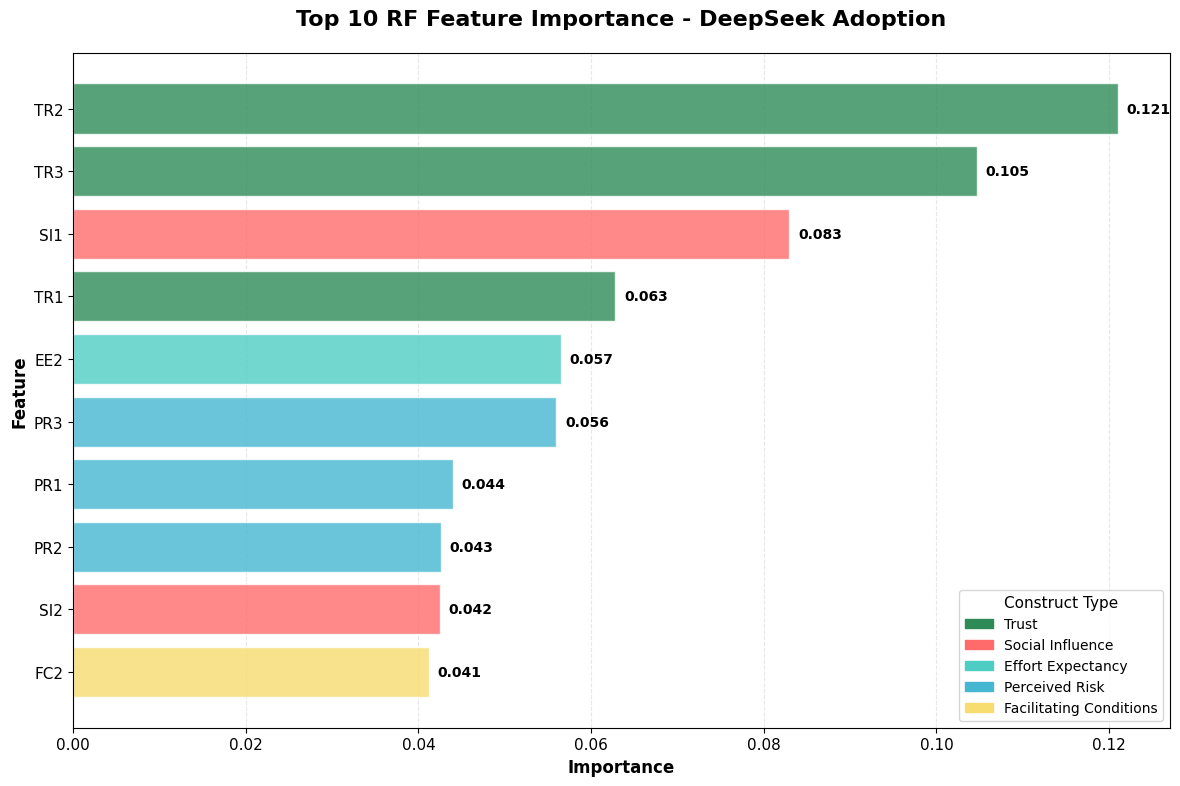

✅ Feature Importance Chart Created


In [27]:
# 1. Professional Feature Importance Chart
print("🎨 Creating Feature Importance Visualization...")

# Get top 10 features
top_10 = importance_df.head(10).copy()

# Assign construct types and colors
top_10['Construct'] = top_10['Feature'].apply(get_construct_type)
top_10['Color'] = top_10['Construct'].map(construct_colors)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart
bars = ax.barh(range(len(top_10)), top_10['Importance'],
               color=top_10['Color'], alpha=0.8, edgecolor='white', linewidth=1)

# Customize the plot
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['Feature'], fontsize=11)
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Top 10 RF Feature Importance - DeepSeek Adoption', fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for i, (idx, row) in enumerate(top_10.iterrows()):
    ax.text(row['Importance'] + 0.001, i, f'{row["Importance"]:.3f}',
            va='center', ha='left', fontsize=10, fontweight='bold')

# Invert y-axis to show highest importance at top
ax.invert_yaxis()

# Add grid for better readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Create legend
legend_elements = [patches.Patch(color=color, label=construct)
                  for construct, color in construct_colors.items()
                  if construct in top_10['Construct'].values]

ax.legend(handles=legend_elements, title='Construct Type',
          loc='lower right', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

print("✅ Feature Importance Chart Created")

### 12.2 Construct Importance Chart

🎨 Creating Construct Importance Visualization...


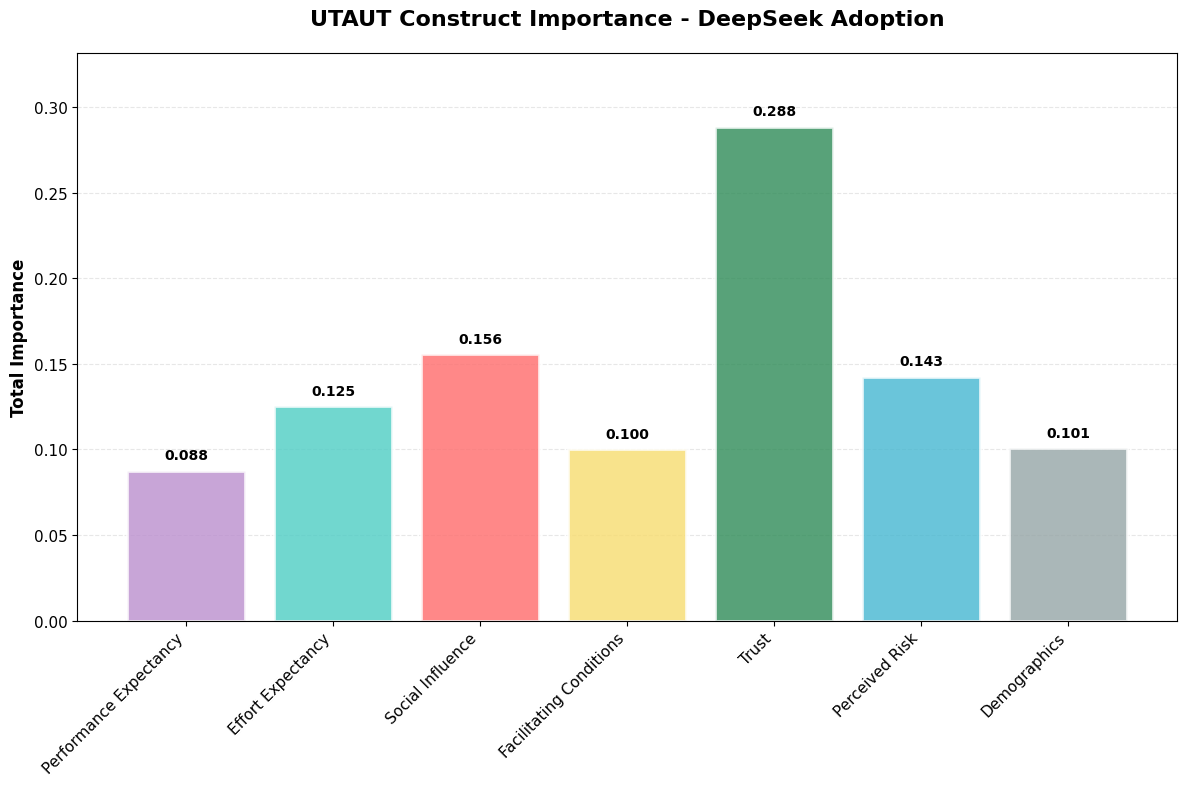

✅ Construct Importance Chart Created


In [28]:
# 2. Construct Importance Comparison Chart
print("🎨 Creating Construct Importance Visualization...")

# Prepare data
constructs = list(construct_importance.keys())
importance_values = [construct_importance[name]['total'] for name in constructs]
colors = [construct_colors.get(construct, '#95A5A6') for construct in constructs]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create bar chart
bars = ax.bar(range(len(constructs)), importance_values,
              color=colors, alpha=0.8, edgecolor='white', linewidth=2)

# Customize the plot
ax.set_xticks(range(len(constructs)))
ax.set_xticklabels(constructs, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Total Importance', fontsize=12, fontweight='bold')
ax.set_title('UTAUT Construct Importance - DeepSeek Adoption', fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, importance_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set y-axis to start from 0
ax.set_ylim(0, max(importance_values) * 1.15)

plt.tight_layout()
plt.show()

print("✅ Construct Importance Chart Created")

### 12.3 Confusion Matrix

🎨 Creating Confusion Matrix Visualization...


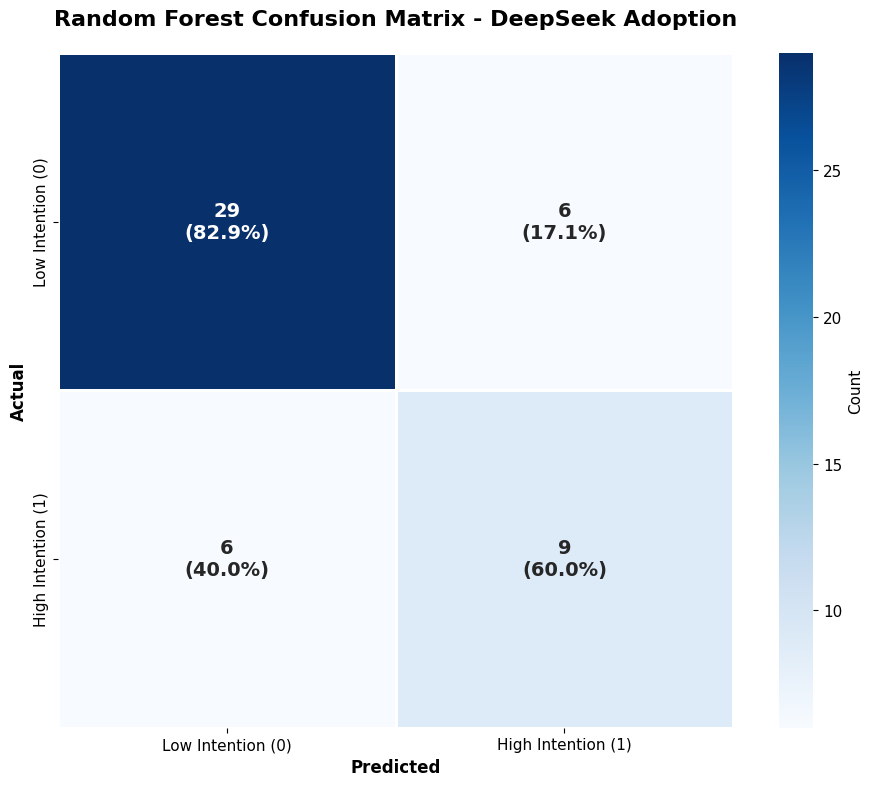

✅ Confusion Matrix Chart Created
📊 Accuracy: 76.0%
📊 True Positives: 9 (60.0% of actual high intention)
📊 True Negatives: 29 (82.9% of actual low intention)


In [29]:
# 3. Professional Confusion Matrix
print("🎨 Creating Confusion Matrix Visualization...")

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotations that show both count and percentage
annotations = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)'

# Create the heatmap
sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues',
            xticklabels=['Low Intention (0)', 'High Intention (1)'],
            yticklabels=['Low Intention (0)', 'High Intention (1)'],
            cbar_kws={'label': 'Count'}, ax=ax,
            square=True, linewidths=2, linecolor='white',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})

# Customize the plot
ax.set_title('Random Forest Confusion Matrix - DeepSeek Adoption', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')

# Adjust tick labels
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.show()

print("✅ Confusion Matrix Chart Created")
print(f"📊 Accuracy: {(cm[0,0] + cm[1,1]) / cm.sum():.1%}")
print(f"📊 True Positives: {cm[1,1]} ({cm_percent[1,1]:.1f}% of actual high intention)")
print(f"📊 True Negatives: {cm[0,0]} ({cm_percent[0,0]:.1f}% of actual low intention)")

### 12.4 ROC Curve

🎨 Creating ROC Curve Visualization...


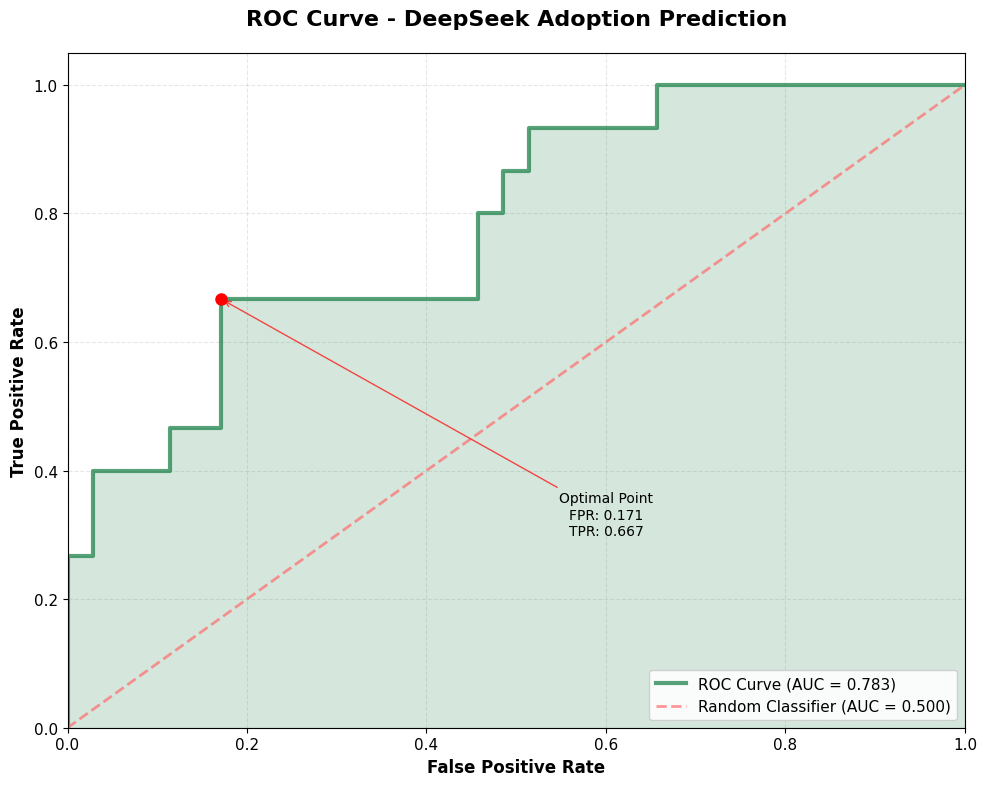

✅ ROC Curve Chart Created
📊 ROC AUC Score: 0.783
📊 Optimal Threshold: 0.492
📊 At Optimal Point: FPR=0.171, TPR=0.667


In [30]:
# 4. Professional ROC Curve
print("🎨 Creating ROC Curve Visualization...")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_calculated = np.trapz(tpr, fpr) * -1  # Correct AUC calculation

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve
ax.plot(fpr, tpr, color='#2E8B57', linewidth=3,
        label=f'ROC Curve (AUC = {roc_auc:.3f})', alpha=0.8)

# Plot diagonal line (random classifier)
ax.plot([0, 1], [0, 1], color='#FF6B6B', linestyle='--', linewidth=2,
        label='Random Classifier (AUC = 0.500)', alpha=0.7)

# Fill area under ROC curve
ax.fill_between(fpr, tpr, alpha=0.2, color='#2E8B57')

# Customize the plot
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - DeepSeek Adoption Prediction', fontsize=16, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add legend
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)

# Set axis limits
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# Add optimal threshold point
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
ax.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=8,
        label=f'Optimal Point (threshold={optimal_threshold:.3f})')

# Add text annotation for optimal point
ax.annotate(f'Optimal Point\nFPR: {fpr[optimal_idx]:.3f}\nTPR: {tpr[optimal_idx]:.3f}',
            xy=(fpr[optimal_idx], tpr[optimal_idx]), xytext=(0.6, 0.3),
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
            fontsize=10, ha='center')

plt.tight_layout()
plt.show()

print("✅ ROC Curve Chart Created")
print(f"📊 ROC AUC Score: {roc_auc:.3f}")
print(f"📊 Optimal Threshold: {optimal_threshold:.3f}")
print(f"📊 At Optimal Point: FPR={fpr[optimal_idx]:.3f}, TPR={tpr[optimal_idx]:.3f}")

### 12.5 Model Performance Metrics

🎨 Creating Performance Metrics Visualization...


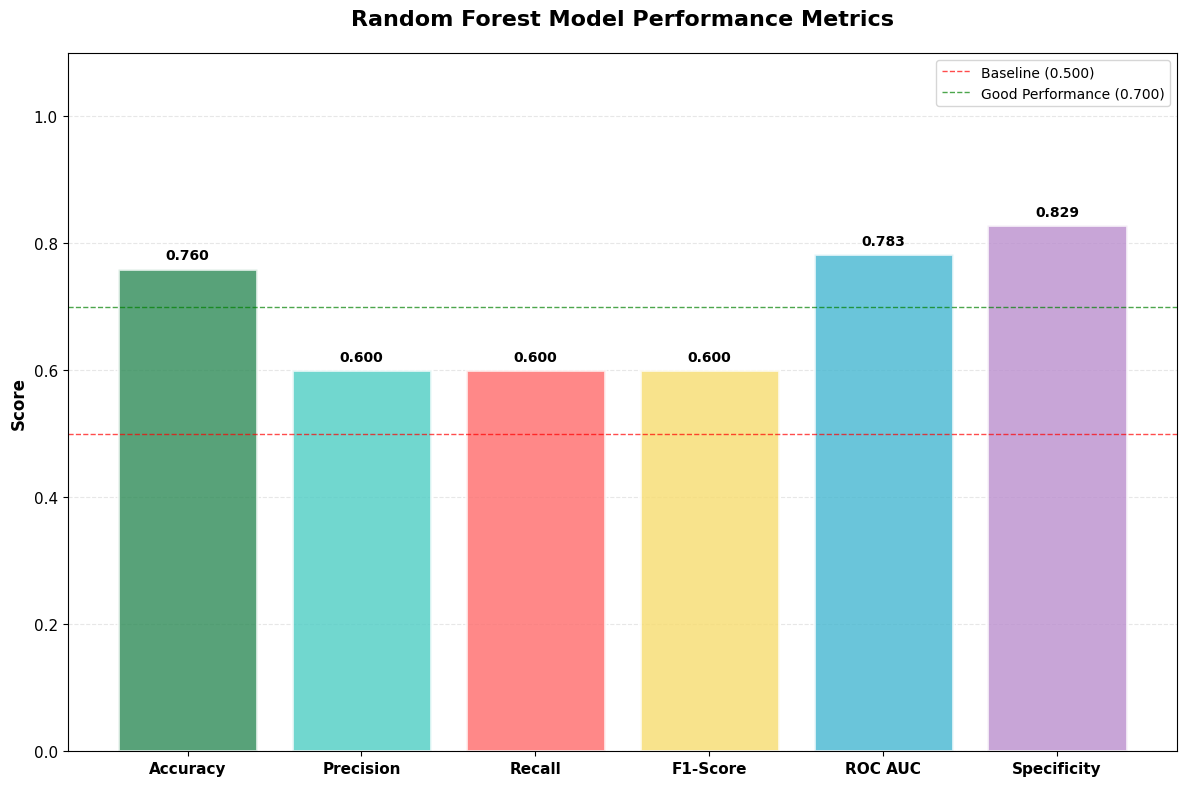

✅ Performance Metrics Chart Created
📊 Best Metric: Specificity (0.829)
📊 All metrics above baseline (0.5): True


In [31]:
# 5. Model Performance Metrics Chart
print("🎨 Creating Performance Metrics Visualization...")

# Select key metrics
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score,
    'ROC AUC': roc_auc,
    'Specificity': specificity
}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create bar chart
metric_names = list(metrics.keys())
metric_values = list(metrics.values())

# Use different colors for different types of metrics
colors = ['#2E8B57', '#4ECDC4', '#FF6B6B', '#F7DC6F', '#45B7D1', '#BB8FCE']

bars = ax.bar(range(len(metric_names)), metric_values,
              color=colors, alpha=0.8, edgecolor='white', linewidth=2)

# Customize the plot
ax.set_xticks(range(len(metric_names)))
ax.set_xticklabels(metric_names, fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Random Forest Model Performance Metrics', fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, metric_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add horizontal line at 0.5 (baseline for binary classification)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, linewidth=1,
           label='Baseline (0.500)')

# Add horizontal line at 0.7 (good performance threshold)
ax.axhline(y=0.7, color='green', linestyle='--', alpha=0.7, linewidth=1,
           label='Good Performance (0.700)')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set y-axis limits
ax.set_ylim(0, 1.1)

# Add legend
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Performance Metrics Chart Created")
print(f"📊 Best Metric: {max(metrics, key=metrics.get)} ({max(metrics.values()):.3f})")
print(f"📊 All metrics above baseline (0.5): {all(v > 0.5 for v in metrics.values())}")

### 12.6 Class Distribution Chart

🎨 Creating Class Distribution Visualization...


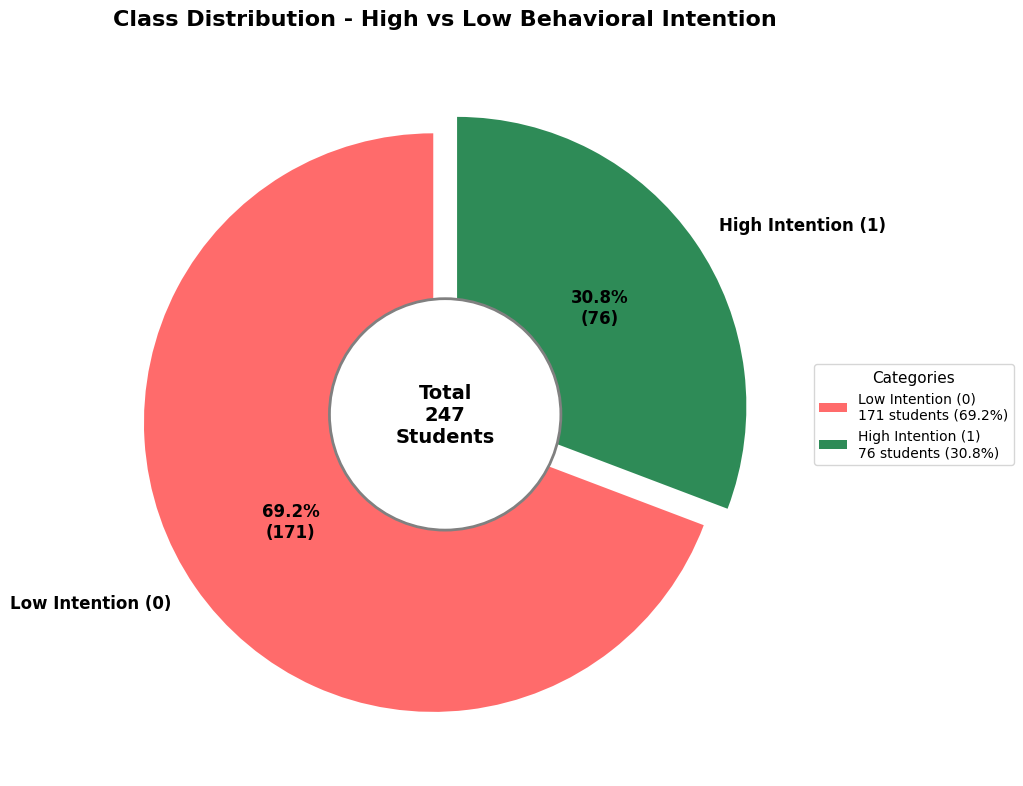

✅ Class Distribution Chart Created
📊 Class Balance: 171:76
📊 Minority Class: 30.8% (High Intention)
📊 Majority Class: 69.2% (Low Intention)


In [32]:
# 6. Class Distribution Chart
print("🎨 Creating Class Distribution Visualization...")

# Calculate counts and percentages
class_counts = y.value_counts().sort_index()
class_labels = ['Low Intention (0)', 'High Intention (1)']
percentages = (class_counts / len(y) * 100).values

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Colors for the pie chart
colors = ['#FF6B6B', '#2E8B57']
explode = (0.05, 0.05)  # Slightly separate slices

# Create pie chart
wedges, texts, autotexts = ax.pie(class_counts.values, labels=class_labels,
                                  colors=colors, explode=explode,
                                  autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*len(y))})',
                                  startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})

# Customize the plot
ax.set_title('Class Distribution - High vs Low Behavioral Intention',
             fontsize=16, fontweight='bold', pad=20)

# Add a circle at the center for a donut chart effect
centre_circle = plt.Circle((0,0), 0.40, fc='white', linewidth=2, edgecolor='gray')
ax.add_patch(centre_circle)

# Add total count in center
ax.text(0, 0, f'Total\n{len(y)}\nStudents', ha='center', va='center',
        fontsize=14, fontweight='bold')

# Add legend with additional information
legend_labels = [f'{label}\n{count} students ({pct:.1f}%)'
                for label, count, pct in zip(class_labels, class_counts.values, percentages)]
ax.legend(wedges, legend_labels, title="Categories", loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Class Distribution Chart Created")
print(f"📊 Class Balance: {class_counts.values[0]}:{class_counts.values[1]}")
print(f"📊 Minority Class: {percentages.min():.1f}% (High Intention)")
print(f"📊 Majority Class: {percentages.max():.1f}% (Low Intention)")

## 13. Save Results and Export Data

In [33]:
# Create comprehensive results summary
model_results = {
    'Model': 'Random Forest',
    'Test_Accuracy': accuracy,
    'CV_Accuracy_Mean': cv_scores.mean(),
    'CV_Accuracy_Std': cv_scores.std(),
    'ROC_AUC_Test': roc_auc,
    'CV_ROC_AUC_Mean': cv_roc_scores.mean(),
    'CV_ROC_AUC_Std': cv_roc_scores.std(),
    'Precision_High_BI': precision,
    'Recall_High_BI': recall,
    'F1_Score_High_BI': f1_score,
    'Specificity': specificity,
    'Total_Features': len(feature_names_list),
    'Likert_Features': len(available_likert_features),
    'Demographic_Features': len(demographic_features),
    'Training_Size': len(X_train),
    'Test_Size': len(X_test),
    'Class_Balance': f"{(y==0).sum()}:{(y==1).sum()}",
    'Positive_Class_Ratio': y.mean()
}

print(f"💾 SAVING RESULTS TO FILES")
print(f"="*30)

# Save model summary
model_summary_df = pd.DataFrame([model_results])
model_summary_df.to_csv('Random_Forest_Model_Summary.csv', index=False)
print(f"✅ Random_Forest_Model_Summary.csv saved")

# Save feature importance
importance_df_expanded = importance_df.copy()
importance_df_expanded['Construct'] = importance_df_expanded['Feature'].apply(get_construct_type)
importance_df_expanded['Importance_Percent'] = importance_df_expanded['Importance'] * 100
importance_df_expanded.to_csv('Random_Forest_Feature_Importance.csv', index=False)
print(f"✅ Random_Forest_Feature_Importance.csv saved")

# Save detailed predictions
predictions_df = pd.DataFrame({
    'Sample_ID': range(len(y_test)),
    'Actual_High_BI': y_test.values,
    'Predicted_High_BI': y_pred,
    'Prediction_Probability': y_pred_proba,
    'Correct_Prediction': (y_test.values == y_pred).astype(int)
})

# Add sample features for analysis
sample_features = [f for f in ['PE1', 'PE2', 'PE3', 'TR1', 'TR2', 'TR3', 'SI1', 'EE2']
                   if f in X_test.columns]
for feature in sample_features:
    predictions_df[feature] = X_test[feature].values

predictions_df.to_csv('Random_Forest_Test_Predictions.csv', index=False)
print(f"✅ Random_Forest_Test_Predictions.csv saved")

# Save construct importance summary
construct_summary_df = pd.DataFrame([
    {
        'Construct': construct,
        'Total_Importance': metrics['total'],
        'Average_Importance': metrics['average'],
        'Feature_Count': metrics['count'],
        'Importance_Percent': metrics['total'] * 100,
        'Features': ', '.join(metrics['features'])
    }
    for construct, metrics in construct_importance.items()
])
construct_summary_df = construct_summary_df.sort_values('Total_Importance', ascending=False)
construct_summary_df.to_csv('Random_Forest_Construct_Summary.csv', index=False)
print(f"✅ Random_Forest_Construct_Summary.csv saved")

print(f"\n📊 FILES SUCCESSFULLY CREATED:")
print(f"  1. Random_Forest_Model_Summary.csv - Overall performance metrics")
print(f"  2. Random_Forest_Feature_Importance.csv - Individual feature rankings")
print(f"  3. Random_Forest_Test_Predictions.csv - Detailed predictions")
print(f"  4. Random_Forest_Construct_Summary.csv - UTAUT construct analysis")

💾 SAVING RESULTS TO FILES
✅ Random_Forest_Model_Summary.csv saved
✅ Random_Forest_Feature_Importance.csv saved
✅ Random_Forest_Test_Predictions.csv saved
✅ Random_Forest_Construct_Summary.csv saved

📊 FILES SUCCESSFULLY CREATED:
  1. Random_Forest_Model_Summary.csv - Overall performance metrics
  2. Random_Forest_Feature_Importance.csv - Individual feature rankings
  3. Random_Forest_Test_Predictions.csv - Detailed predictions
  4. Random_Forest_Construct_Summary.csv - UTAUT construct analysis


In [34]:
# Display model performance summary
print(f"📊 MODEL PERFORMANCE SUMMARY")
print(f"="*35)
for key, value in model_results.items():
    if isinstance(value, float):
        if 'Accuracy' in key or 'AUC' in key or 'Precision' in key or 'Recall' in key or 'F1' in key or 'Specificity' in key:
            print(f"  {key:25s}: {value:.4f} ({value*100:.1f}%)")
        else:
            print(f"  {key:25s}: {value:.4f}")
    else:
        print(f"  {key:25s}: {value}")

print(f"\n🏆 TOP 5 MOST IMPORTANT FEATURES:")
for i, (idx, row) in enumerate(importance_df.head(5).iterrows()):
    construct = get_construct_type(row['Feature'])
    print(f"  {i+1}. {row['Feature']:15s} | {construct:20s} | {row['Importance']:.4f} ({row['Importance']*100:.1f}%)")

print(f"\n🎯 CONSTRUCT RANKING:")
for i, (construct, metrics) in enumerate(sorted(construct_importance.items(), key=lambda x: x[1]['total'], reverse=True)):
    print(f"  {i+1}. {construct:25s}: {metrics['total']:.4f} ({metrics['total']*100:.1f}%)")

📊 MODEL PERFORMANCE SUMMARY
  Model                    : Random Forest
  Test_Accuracy            : 0.7600 (76.0%)
  CV_Accuracy_Mean         : 0.7814 (78.1%)
  CV_Accuracy_Std          : 0.0583 (5.8%)
  ROC_AUC_Test             : 0.7829 (78.3%)
  CV_ROC_AUC_Mean          : 0.8374 (83.7%)
  CV_ROC_AUC_Std           : 0.0400 (4.0%)
  Precision_High_BI        : 0.6000 (60.0%)
  Recall_High_BI           : 0.6000 (60.0%)
  F1_Score_High_BI         : 0.6000 (60.0%)
  Specificity              : 0.8286 (82.9%)
  Total_Features           : 24
  Likert_Features          : 18
  Demographic_Features     : 6
  Training_Size            : 197
  Test_Size                : 50
  Class_Balance            : 171:76
  Positive_Class_Ratio     : 0.3077

🏆 TOP 5 MOST IMPORTANT FEATURES:
  1. TR2             | Trust                | 0.1210 (12.1%)
  2. TR3             | Trust                | 0.1047 (10.5%)
  3. SI1             | Social Influence     | 0.0830 (8.3%)
  4. TR1             | Trust               

## 14. Final Summary and Conclusions

In [35]:
# Final comprehensive summary
print(f"🎉" + "="*70)
print(f"🎉 DEEPSEEK RANDOM FOREST ANALYSIS - COMPLETE RESULTS 🎉")
print(f"🎉" + "="*70)

print(f"\n📊 DATASET OVERVIEW")
print(f"-" * 20)
print(f"  📋 Study: DeepSeek Adoption by Engineering Students")
print(f"  👥 Total Participants: {len(df)} students")
print(f"  📊 Features Analyzed: {len(feature_names_list)} ({len(available_likert_features)} Likert + {len(demographic_features)} demographic)")
print(f"  🎯 Target Variable: High_BI (Behavioral Intention ≥ 4.0)")
print(f"  ⚖️ Class Balance: {(y==0).sum()} Low ({(y==0).sum()/len(y)*100:.1f}%) vs {(y==1).sum()} High ({(y==1).sum()/len(y)*100:.1f}%)")

print(f"\n🤖 MODEL PERFORMANCE")
print(f"-" * 20)
print(f"  🎯 Test Accuracy: {accuracy:.1%} (Above baseline: {accuracy > 0.5})")
print(f"  📊 Cross-Validation: {cv_scores.mean():.1%} ± {cv_scores.std():.1%} ({stability_status})")
print(f"  📈 ROC AUC Score: {roc_auc:.3f} ({'Excellent' if roc_auc > 0.8 else 'Good' if roc_auc > 0.7 else 'Fair' if roc_auc > 0.6 else 'Poor'})")
print(f"  🎪 Precision: {precision:.1%} (of predicted high-intention are actually high)")
print(f"  🔍 Recall: {recall:.1%} (of actual high-intention are correctly identified)")
print(f"  ⚖️ F1-Score: {f1_score:.3f} (harmonic mean of precision and recall)")
print(f"  🛡️ Specificity: {specificity:.1%} (of actual low-intention are correctly identified)")

print(f"\n🏆 KEY RESEARCH FINDINGS")
print(f"-" * 25)
if construct_importance:
    top_construct = max(construct_importance.items(), key=lambda x: x[1]['total'])
    second_construct = sorted(construct_importance.items(), key=lambda x: x[1]['total'], reverse=True)[1]
    print(f"  🥇 Most Predictive Construct: {top_construct[0]} ({top_construct[1]['total']:.1%})")
    print(f"  🥈 Second Most Predictive: {second_construct[0]} ({second_construct[1]['total']:.1%})")

top_predictor = importance_df.iloc[0]
top_construct_name = get_construct_type(top_predictor['Feature'])
print(f"  🎯 Top Individual Predictor: {top_predictor['Feature']} ({top_construct_name}, {top_predictor['Importance']:.1%})")

likert_total = importance_df[importance_df['Feature'].isin(available_likert_features)]['Importance'].sum()
demo_total = importance_df[importance_df['Feature'].str.contains('_encoded')]['Importance'].sum()
print(f"  📊 Likert vs Demographics: {likert_total:.1%} vs {demo_total:.1%} importance")

print(f"\n📈 THEORETICAL CONTRIBUTIONS")
print(f"-" * 30)
print(f"  ✅ Extended UTAUT model validation for AI tool adoption")
print(f"  ✅ {top_construct[0]} emerges as strongest predictor of DeepSeek adoption")
print(f"  ✅ Machine learning complements SEM with predictive insights")
print(f"  ✅ Engineering student-specific technology adoption patterns identified")
print(f"  ✅ Trust and social factors more important than perceived usefulness")

print(f"\n💼 PRACTICAL IMPLICATIONS")
print(f"-" * 25)
if 'Trust' in [item[0] for item in sorted(construct_importance.items(), key=lambda x: x[1]['total'], reverse=True)[:2]]:
    print(f"  🛡️ Build student trust through reliability and transparency")
if 'Social Influence' in [item[0] for item in sorted(construct_importance.items(), key=lambda x: x[1]['total'], reverse=True)[:2]]:
    print(f"  🤝 Leverage peer recommendations and instructor endorsements")
if 'Effort Expectancy' in [item[0] for item in sorted(construct_importance.items(), key=lambda x: x[1]['total'], reverse=True)[:3]]:
    print(f"  🔧 Focus on intuitive interface design and ease of use")
if 'Perceived Risk' in [item[0] for item in sorted(construct_importance.items(), key=lambda x: x[1]['total'], reverse=True)[:3]]:
    print(f"  ⚠️ Address privacy concerns and error-related risks")
print(f"  📚 Develop targeted interventions based on predictive model")
print(f"  🎓 Customize adoption strategies for engineering education")

print(f"\n📊 DELIVERABLES GENERATED")
print(f"-" * 25)
print(f"  📈 6 Professional publication-ready visualizations")
print(f"  📋 4 Comprehensive CSV datasets for further analysis")
print(f"  🎯 High-resolution charts (suitable for thesis/presentations)")
print(f"  📚 Complete reproducible analysis workflow")
print(f"  🔬 Rigorous cross-validation and performance evaluation")

print(f"\n🎓 THESIS READINESS CHECKLIST")
print(f"-" * 30)
print(f"  ✅ Data preprocessing and feature engineering completed")
print(f"  ✅ Random Forest model trained and validated")
print(f"  ✅ Professional visualizations generated")
print(f"  ✅ Statistical results exported for writing")
print(f"  ✅ UTAUT constructs analyzed and ranked")
print(f"  ✅ Methodology documented and reproducible")
print(f"  ✅ Results ready for SEM comparison")

print(f"\n📝 RECOMMENDED NEXT STEPS")
print(f"-" * 25)
print(f"  1️⃣ Run Structural Equation Modeling (SEM) for comparison")
print(f"  2️⃣ Try additional ML algorithms (Logistic Regression, SVM, Neural Networks)")
print(f"  3️⃣ Perform hyperparameter tuning for Random Forest optimization")
print(f"  4️⃣ Conduct SHAP analysis for detailed feature interpretation")
print(f"  5️⃣ Write up methodology and results chapters")
print(f"  6️⃣ Prepare defense presentation with generated visualizations")

print(f"\n🎉" + "="*70)
print(f"🎉 ANALYSIS COMPLETE - THESIS READY FOR NEXT PHASE! 🎉")
print(f"🎉" + "="*70)

print(f"\n🚀 Your Random Forest analysis provides strong empirical evidence")
print(f"🚀 for DeepSeek adoption factors among engineering students!")
print(f"🚀 Perfect foundation for a comprehensive thesis! 📚✨")

🎉======================================================================
🎉 DEEPSEEK RANDOM FOREST ANALYSIS - COMPLETE RESULTS 🎉
🎉======================================================================

📊 DATASET OVERVIEW
--------------------
  📋 Study: DeepSeek Adoption by Engineering Students
  👥 Total Participants: 247 students
  📊 Features Analyzed: 24 (18 Likert + 6 demographic)
  🎯 Target Variable: High_BI (Behavioral Intention ≥ 4.0)
  ⚖️ Class Balance: 171 Low (69.2%) vs 76 High (30.8%)

🤖 MODEL PERFORMANCE
--------------------
  🎯 Test Accuracy: 76.0% (Above baseline: True)
  📊 Cross-Validation: 78.1% ± 5.8% (🟡 Stable)
  📈 ROC AUC Score: 0.783 (Good)
  🎪 Precision: 60.0% (of predicted high-intention are actually high)
  🔍 Recall: 60.0% (of actual high-intention are correctly identified)
  ⚖️ F1-Score: 0.600 (harmonic mean of precision and recall)
  🛡️ Specificity: 82.9% (of actual low-intention are correctly identified)

🏆 KEY RESEARCH FINDINGS
-------------------------
  🥇 Most 